# Task 4

## Task: Banknote Authentication Classification

In this task, you will work with the dataset provided in the file **`data_banknote_authentication.csv`**

Your objective is to build and evaluate classification models to predict the authenticity of banknotes.

You should:

- Load and explore the dataset.
- Build two classification models:
  - **Decision Tree**
  - **Random Forest**
- Use **GridSearchCV** to optimize the hyperparameters of each model.
- Evaluate the performance of both models using:
  - **Confusion Matrix**
  - **Classification Report**

Finally, **compare the performance of the two models** and discuss which model performs better for this dataset.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ---------------------------------------------------------
# 1. LOAD AND EXPLORE THE DATASET
# ---------------------------------------------------------
# We load the dataset using pandas. 
# The dataset has 5 columns: 4 features (Variance, Skewness, Curtosis, Entropy) and 1 target (Class).
df = pd.read_csv('data_banknote_authentication.csv')
df.info()
# Separate the features (X) from the target label (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Split the dataset into 80% training and 20% testing sets.
# Using 'stratify=y' ensures that both the train and test sets have the same proportion of classes.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Variance_Wavelet  1372 non-null   float64
 1   Skewness_Wavelet  1372 non-null   float64
 2   Curtosis_Wavelet  1372 non-null   float64
 3   Image_Entropy     1372 non-null   float64
 4   Class             1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [24]:



# ---------------------------------------------------------
# 2. DECISION TREE CLASSIFIER & HYPERPARAMETER TUNING
# ---------------------------------------------------------
print("--- Training Decision Tree ---")

# Define the hyperparameters to tune:
# - criterion: Measures the quality of a split (gini or entropy).
# - max_depth: The maximum depth of the tree (prevents overfitting).
# - max_leaf_nodes: Maximum number of leaves the tree can have.
dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15],
    'max_leaf_nodes': [None, 10, 20, 50]
}

# Initialize the Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# Set up GridSearchCV to test all combinations using 5-fold cross-validation
dt_grid = GridSearchCV(dt, dt_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
dt_grid.fit(X_train, y_train)

# Extract the best model from grid search
best_dt = dt_grid.best_estimator_

# Predict on the unseen test data
y_pred_dt = best_dt.predict(X_test)






--- Training Decision Tree ---


In [25]:
# ---------------------------------------------------------
# 3. RANDOM FOREST CLASSIFIER & HYPERPARAMETER TUNING
# ---------------------------------------------------------
print("--- Training Random Forest ---")

# Define the hyperparameters to tune:
# - n_estimators: The number of trees in the forest.
# - max_depth: The maximum depth of each individual tree.
# - max_features: The number of features to consider when looking for the best split. 
#                 (e.g., 'sqrt' forces trees to use different subsets of features, ensuring diversity).
rf_param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2', 0.5] 
}

# Initialize the Random Forest model
rf = RandomForestClassifier(random_state=42)

# Set up GridSearchCV to test all combinations using 5-fold cross-validation
rf_grid = GridSearchCV(rf, rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)

# Extract the best model from grid search
best_rf = rf_grid.best_estimator_

# Predict on the unseen test data
y_pred_rf = best_rf.predict(X_test)

--- Training Random Forest ---


In [26]:

# ---------------------------------------------------------
# 4. EVALUATION & COMPARISON
# ---------------------------------------------------------
print("\n================ DECISION TREE RESULTS ================")
print("Best Hyperparameters:", dt_grid.best_params_)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt, digits=3))




================ DECISION TREE RESULTS ================
Best Hyperparameters: {'criterion': 'entropy', 'max_depth': None, 'max_leaf_nodes': 20}

Confusion Matrix:
 [[151   2]
 [  0 122]]

Classification Report:
               precision    recall  f1-score   support

           0      1.000     0.987     0.993       153
           1      0.984     1.000     0.992       122

    accuracy                          0.993       275
   macro avg      0.992     0.993     0.993       275
weighted avg      0.993     0.993     0.993       275



In [27]:
print("\n================ RANDOM FOREST RESULTS ================")
print("Best Hyperparameters:", rf_grid.best_params_)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, digits=3))



================ RANDOM FOREST RESULTS ================
Best Hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 150}

Confusion Matrix:
 [[152   1]
 [  0 122]]

Classification Report:
               precision    recall  f1-score   support

           0      1.000     0.993     0.997       153
           1      0.992     1.000     0.996       122

    accuracy                          0.996       275
   macro avg      0.996     0.997     0.996       275
weighted avg      0.996     0.996     0.996       275



DECISION TREE:

Confusion Matrix: 151 Correct Genuine (True Negatives) | 2 Misclassified (False Positives)

0 Misclassified (False Negatives) | 122 Correct Forged (True Positives)

Accuracy / F1-Score: 99.3%

--------------------------------------------------------------------------------------------------------------------------------------------
RANDOM FOREST:

Confusion Matrix: 152 Correct Genuine (True Negatives) | 1 Misclassified (False Positive)

0 Misclassified (False Negatives) | 122 Correct Forged (True Positives)

Accuracy / F1-Score: 99.6%

--------------------------------------------------------------------------------------------------------------------------------------------
The Random Forest performs slightly better than the Decision Tree on this dataset.

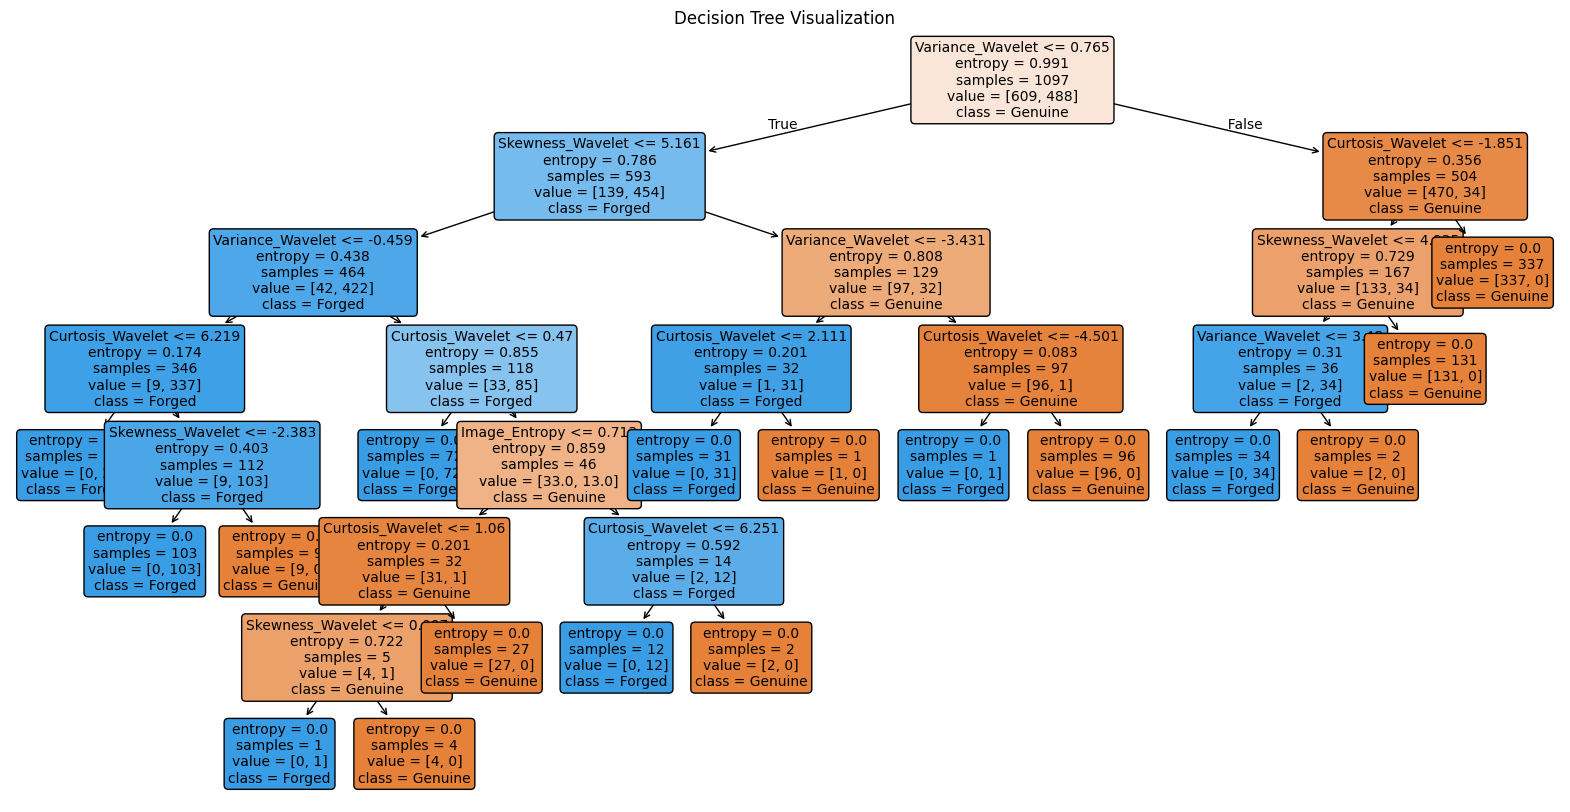

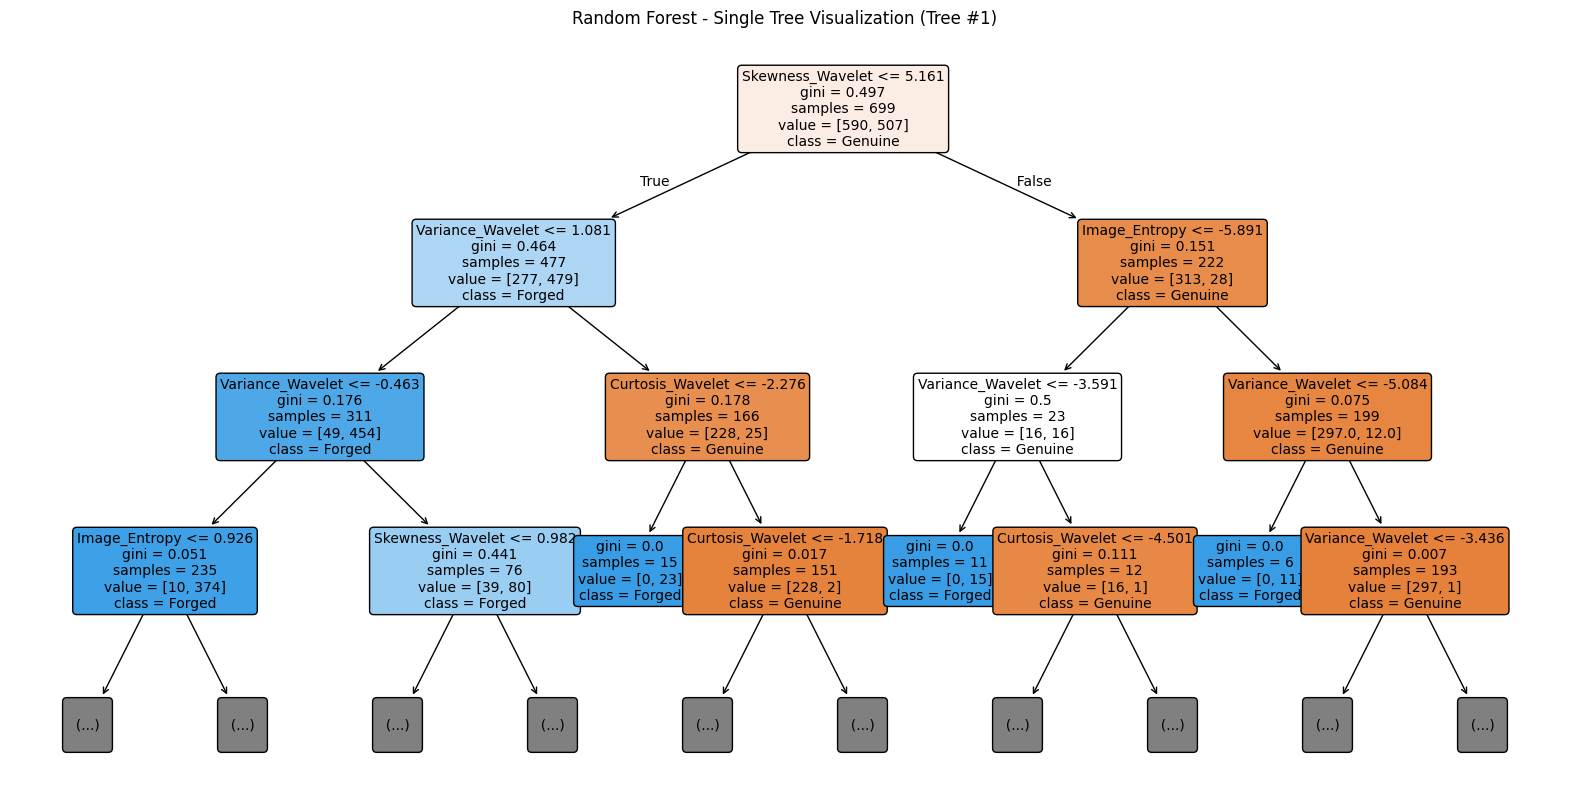

In [28]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# ---------------------------------------------------------
# VISUALIZE THE DECISION TREE
# ---------------------------------------------------------
plt.figure(figsize=(20, 10))
# We plot the best decision tree found by GridSearchCV
plot_tree(best_dt, 
          feature_names=X.columns, 
          class_names=['Genuine', 'Forged'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title('Decision Tree Visualization')
plt.show()

# ---------------------------------------------------------
# VISUALIZE THE RANDOM FOREST (Just One Tree)
# ---------------------------------------------------------
# A Random Forest has 150 trees, so we cannot plot all of them easily.
# Instead, we pull out just the very first tree (index 0) to visualize it.
plt.figure(figsize=(20, 10))
plot_tree(best_rf.estimators_[0], 
          feature_names=X.columns, 
          class_names=['Genuine', 'Forged'], 
          filled=True, 
          rounded=True, 
          fontsize=10, 
          max_depth=3) # We limit the depth to 3 just so the image isn't too crowded
plt.title('Random Forest - Single Tree Visualization (Tree #1)')
plt.show()